# Replication Results: Chen, Kelly, and Xiu (2022)
## Expected Returns and Large Language Models

Chen, Kelly, and Xiu (2022) demonstrate that large language model
embeddings of financial news articles contain substantial information
about future stock returns. Their method encodes news text into
high-dimensional vector representations, then trains rolling-window
logistic regression classifiers to predict the sign of subsequent
3-day compound returns. They find out-of-sample accuracy of roughly
51--54% across multiple models, consistently beating the 50% random
baseline.

We partially replicate their analysis using the RavenPack DJ press
release dataset available through WRDS. Our replication differs from the
original in two key ways. First, we use short press-release *headlines*
rather than full article text. Second, we limit the embedding models to
TF-IDF, DistilBERT, BERT, and OpenAI (`text-embedding-3-small` and
`text-embedding-3-large`), rather than the paper's comprehensive
model suite. Despite these differences, the pipeline structure---filtering
funnel, rolling window scheme, and accuracy metric---follows the original
paper precisely.

In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from settings import config

DATA_DIR = Path(config("DATA_DIR"))
OUTPUT_DIR = Path(config("OUTPUT_DIR"))

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.dpi": 150,
})

## Data

Raw news data are obtained from the RavenPack DJ press release tables
on WRDS, which contain Dow Jones press release coverage for US-listed
equities. We pre-filter at the pull stage to articles with:
(i) country code "US"; (ii) entity type "COMP" (corporate entity);
and (iii) relevance score equal to 100 (maximum relevance).
Stock returns are from the CRSP daily file, restricted to ordinary
common shares.

### Table 1: News Filtering Funnel

Observation counts at each stage of the data construction pipeline.
Each row applies one filter sequentially; the rightmost column shows
how many observations are removed at that stage relative to the prior.

In [2]:
STAGE_LABELS = {
    "0_raw": "Raw headlines (US, COMP, relevance=100)",
    "1_single_entity": "Single-entity filter (one PERMNO per story)",
    "2_has_return": "Has valid CRSP daily return",
    "3_length_filter": "Headline length >= 5 characters",
    "4_deduplicated": "After deduplication (per PERMNO-date)",
}

with open(DATA_DIR / "ravenpack_stage_counts.json") as f:
    stage_counts = json.load(f)

raw_count = stage_counts["0_raw"]
rows = []
prev_count = None
for key in sorted(stage_counts.keys()):
    count = stage_counts[key]
    label = STAGE_LABELS.get(key, key)
    pct_raw = count / raw_count * 100

    if prev_count is not None and prev_count > 0:
        dropped = prev_count - count
        pct_dropped = dropped / prev_count * 100
        dropped_str = f"{dropped:,} ({pct_dropped:.1f}%)"
    else:
        dropped_str = "\u2014"

    rows.append({
        "Stage": label,
        "Observations": f"{count:,}",
        "% of Raw": f"{pct_raw:.1f}%",
        "Dropped from Prior": dropped_str,
    })
    prev_count = count

df_funnel = pd.DataFrame(rows)
df_funnel.style.hide(axis="index").set_caption(
    "Table 1: News Dataset Filtering Funnel"
)

Stage,Observations,% of Raw,Dropped from Prior
"Raw headlines (US, COMP, relevance=100)","1,747,692",100.0%,—
Single-entity filter (one PERMNO per story),"1,747,692",100.0%,0 (0.0%)
Has valid CRSP daily return,"1,304,504",74.6%,"443,188 (25.4%)"
Headline length >= 5 characters,"1,304,504",74.6%,0 (0.0%)
After deduplication (per PERMNO-date),"617,471",35.3%,"687,033 (52.7%)"


Articles published between 9:00 and 9:30 AM Eastern Time are shifted
to the following trading day to avoid contaminating labels with pre-open
information, following Chen, Kelly, and Xiu (2022).

### Table 2: Dataset Summary Statistics

Summary statistics for the cleaned RavenPack DJ press release sample,
after the full filtering funnel above.

In [3]:
df_clean = pl.read_parquet(DATA_DIR / "ravenpack_clean.parquet")

n_articles = len(df_clean)
n_unique_stories = df_clean["rp_story_id"].n_unique()
date_min = df_clean["article_date"].min()
date_max = df_clean["article_date"].max()

daily_stats = df_clean.group_by("article_date").agg(
    pl.len().alias("n_articles"),
    pl.col("permno").n_unique().alias("n_stocks"),
)
n_days = len(daily_stats)
avg_articles_per_day = daily_stats["n_articles"].mean()
avg_stocks_per_day = daily_stats["n_stocks"].mean()
n_unique_stocks = df_clean["permno"].n_unique()

summary_rows = [
    ("Date range (start)", str(date_min)),
    ("Date range (end)", str(date_max)),
    ("Total articles", f"{n_articles:,}"),
    ("Unique stories", f"{n_unique_stories:,}"),
    ("Trading days with news", f"{n_days:,}"),
    ("Avg. articles per trading day", f"{avg_articles_per_day:.1f}"),
    ("Avg. unique stocks per trading day", f"{avg_stocks_per_day:.1f}"),
    ("Unique stocks (PERMNO)", f"{n_unique_stocks:,}"),
]

df_summary = pd.DataFrame(summary_rows, columns=["Statistic", "Value"])
df_summary.style.hide(axis="index").set_caption(
    "Table 2: Dataset Summary Statistics"
)

Statistic,Value
Date range (start),2010-12-01
Date range (end),2024-12-31
Total articles,"617,471"
Unique stories,"617,471"
Trading days with news,"2,701"
Avg. articles per trading day,228.6
Avg. unique stocks per trading day,186.1
Unique stocks (PERMNO),"6,493"


### Table 3: Text Statistics

Percentile distribution of headline length measured in characters,
BERT tokens, and words. These distributions characterize the input
length available to each embedding model and can be compared to the
full-article lengths reported in Chen, Kelly, and Xiu (2022).
BERT token counts use the `bert-base-uncased` tokenizer without
special tokens.

RavenPack headlines are considerably shorter than the full articles
analyzed in the original paper, which reduces information content
but also simplifies embedding computation.

In [4]:
with open(DATA_DIR / "text_stats.json") as f:
    text_stats = json.load(f)

pct_cols = [f"{p}th" for p in text_stats["percentiles"]]
text_rows = []
for measure, label in [
    ("characters", "# characters"),
    ("bert_tokens", "# BERT tokens"),
    ("words", "# words"),
]:
    row = {"Measure": label}
    for col in pct_cols:
        row[col] = f"{text_stats[measure][col]:.0f}"
    row["Mean"] = f"{text_stats[measure]['mean']:.1f}"
    text_rows.append(row)

df_text = pd.DataFrame(text_rows)
df_text.style.hide(axis="index").set_caption(
    f"Table 3: Text Statistics (sample of {text_stats['sample_size']:,} headlines)"
)

Measure,1th,25th,50th,75th,99th,Mean
# characters,35,62,80,105,199,87.5
# BERT tokens,6,12,15,21,44,17.2
# words,5,9,12,15,30,12.7


### News Volume Over Time

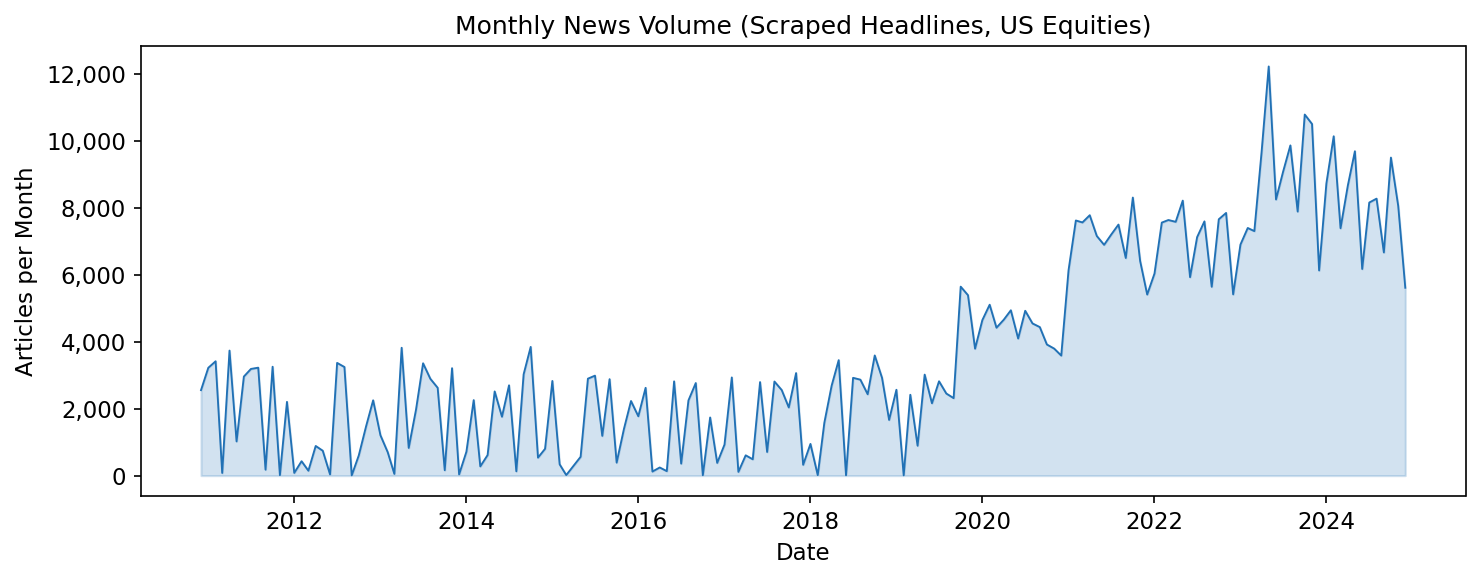

In [5]:
monthly = (
    df_clean.with_columns(
        pl.col("article_date").cast(pl.Date).dt.truncate("1mo").alias("month")
    )
    .group_by("month")
    .len()
    .sort("month")
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly["month"].to_list(), monthly["len"].to_list(), color="#2171b5", linewidth=0.9)
ax.fill_between(monthly["month"].to_list(), monthly["len"].to_list(), alpha=0.2, color="#2171b5")
ax.set_xlabel("Date")
ax.set_ylabel("Articles per Month")
ax.set_title("Monthly News Volume (Scraped Headlines, US Equities)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig.tight_layout()
plt.show()

## Methodology

### Return Labels

Following Chen, Kelly, and Xiu (2022), we compute the compound return
over the 3-day window $(-1, +1)$ trading days relative to the article
date:

$$r_{\text{window}} = \prod_{k=-1}^{1} (1 + r_{t+k}) - 1$$

where $t$ is the article date (or next trading day after the
opening-window shift) and $k$ indexes trading days. The binary label is
$y = \mathbf{1}[r_{\text{window}} > 0]$.

### Embeddings

We compute five sets of embeddings:

| Model | Dimension | Source |
|-------|-----------|--------|
| TF-IDF + SVD | 64 | Fit on corpus (sklearn) |
| DistilBERT | 768 | `distilbert-base-uncased` (HuggingFace) |
| BERT | 768 | `bert-base-uncased` (HuggingFace) |
| OpenAI-S | 1,536 | `text-embedding-3-small` (API) |
| OpenAI-L | 3,072 | `text-embedding-3-large` (API) |

BERT and DistilBERT embeddings use mean-pooled last-hidden-state
representations, excluding padding tokens from the mean.

### Rolling Window Classification

For each out-of-sample year $t$, we train an L2-regularized logistic
regression classifier on the 6-year period $[t-8, t-3)$, validate the
regularization strength $C \in \{10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}, 1\}$
on the 2-year period $[t-3, t-1)$, and evaluate on year $[t-1, t)$.
Features are standardized (zero mean, unit variance) using training-set
statistics. Train, validation, and test sets are randomly subsampled to
$N = 100{,}000$ per split per year.

## Results

### Return Distribution by Label

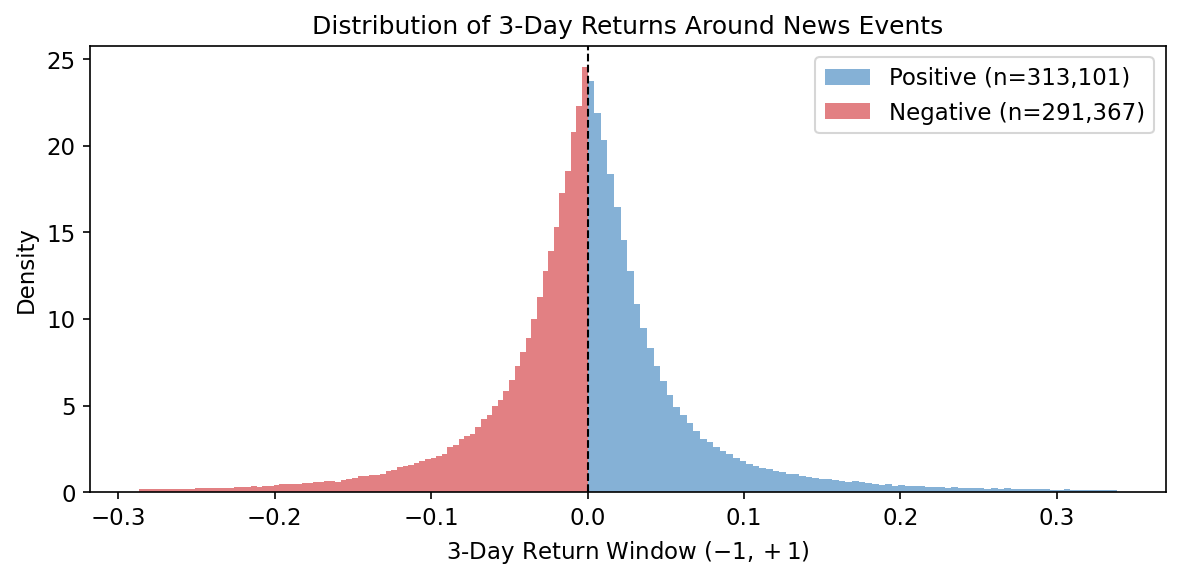

In [6]:
df_labeled = pl.read_parquet(DATA_DIR / "labeled_dataset.parquet")
ret = df_labeled.select("ret_window", "label").drop_nulls()

# Clip extreme returns for visualization
lo = ret["ret_window"].quantile(0.01)
hi = ret["ret_window"].quantile(0.99)
ret = ret.filter((pl.col("ret_window") >= lo) & (pl.col("ret_window") <= hi))

fig, ax = plt.subplots(figsize=(8, 4))
for label_val, color, name in [(1, "#2171b5", "Positive"), (0, "#cb181d", "Negative")]:
    subset = ret.filter(pl.col("label") == label_val)["ret_window"].to_numpy()
    ax.hist(subset, bins=80, alpha=0.55, color=color,
            label=f"{name} (n={len(subset):,})", density=True)

ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("3-Day Return Window $(-1, +1)$")
ax.set_ylabel("Density")
ax.set_title("Distribution of 3-Day Returns Around News Events")
ax.legend()
fig.tight_layout()
plt.show()

The vertical dashed line at zero separates the positive-label (right)
and negative-label (left) classes used for binary classification.

### Table 5: Out-of-Sample Classification Accuracy

Yearly accuracy for predicting the sign of the 3-day return window
around news articles. Each column reports a different embedding model;
the bottom row averages across all OOS years. The 50% threshold
represents random-guess performance.

In [7]:
MODEL_DISPLAY_NAMES = {
    "tfidf": "TF-IDF",
    "distilbert": "DistilBERT",
    "openai_small": "OpenAI-S",
    "bert": "BERT",
    "openai": "OpenAI-L",
}

results_dict = {}
for json_path in sorted(DATA_DIR.glob("rolling_results_*.json")):
    stem = json_path.stem
    if stem.endswith("_checkpoint"):
        continue
    model_name = stem.replace("rolling_results_", "")
    display_name = MODEL_DISPLAY_NAMES.get(model_name, model_name)
    with open(json_path) as f:
        data = json.load(f)
    results_dict[display_name] = {int(k): v for k, v in data.items()}

if results_dict:
    all_years = sorted(set(y for r in results_dict.values() for y in r.keys()))
    model_names = list(results_dict.keys())

    rows = []
    for year in all_years:
        row = {"Year": year}
        for m in model_names:
            if year in results_dict[m]:
                row[m] = f"{results_dict[m][year]['accuracy'] * 100:.2f}%"
            else:
                row[m] = "\u2014"
        rows.append(row)

    # Average row
    avg_row = {"Year": "Average"}
    for m in model_names:
        accs = [v["accuracy"] * 100 for v in results_dict[m].values()]
        avg_row[m] = f"{np.mean(accs):.2f}%"
    rows.append(avg_row)

    df_table5 = pd.DataFrame(rows).set_index("Year")
    display(df_table5.style.set_caption("Table 5: Out-of-Sample Classification Accuracy"))
else:
    print("No rolling results found. Run train_rolling_model.py first.")

,BERT,DistilBERT,OpenAI-L,OpenAI-S,TF-IDF
Year,,,,,
2018,50.12%,50.32%,51.35%,50.71%,50.48%
2019,54.17%,54.38%,54.39%,54.14%,53.21%
2020,53.41%,53.56%,54.32%,53.77%,53.70%
2021,52.90%,53.25%,53.80%,53.93%,53.62%
2022,51.15%,51.25%,53.68%,53.52%,49.93%
2023,53.18%,53.05%,55.07%,54.27%,51.59%
2024,52.54%,52.58%,53.28%,52.81%,52.04%
Average,52.50%,52.63%,53.70%,53.31%,52.08%


### OOS Accuracy Over Time

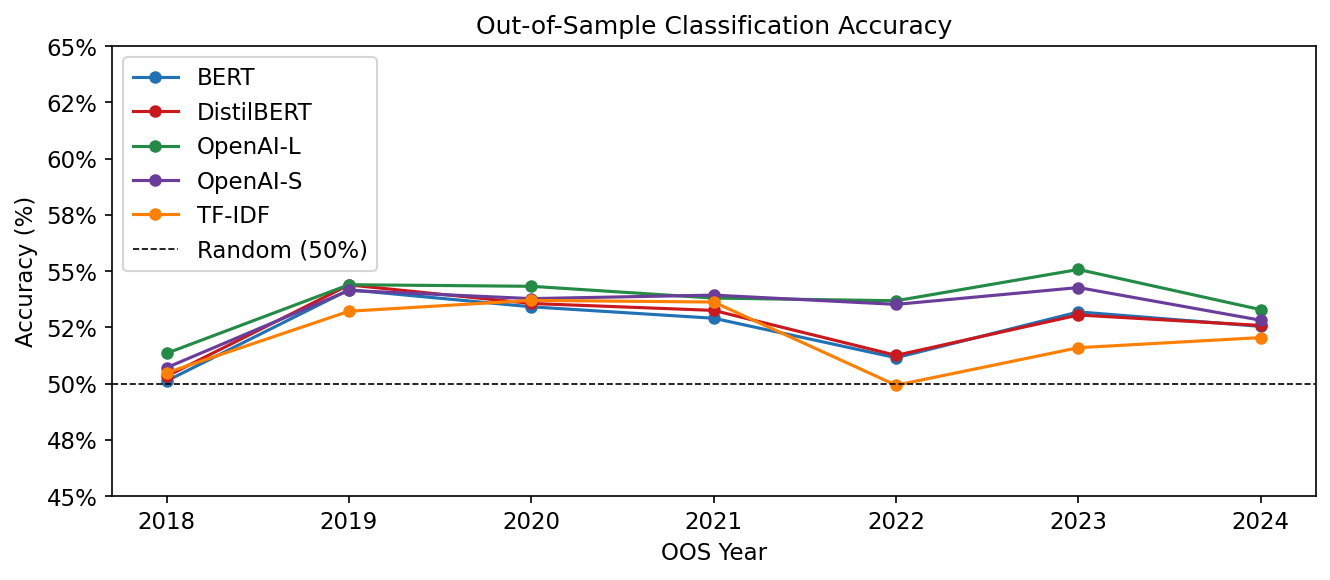

In [8]:
if results_dict:
    colors = ["#2171b5", "#cb181d", "#238b45", "#6a3d9a", "#ff7f00"]

    fig, ax = plt.subplots(figsize=(9, 4))
    for i, (model_name, model_results) in enumerate(results_dict.items()):
        years = sorted(model_results.keys())
        accs = [model_results[y]["accuracy"] * 100 for y in years]
        color = colors[i % len(colors)]
        ax.plot(years, accs, marker="o", color=color, label=model_name, linewidth=1.5, markersize=5)

    ax.axhline(50, color="black", linewidth=0.8, linestyle="--", label="Random (50%)")
    ax.set_xlabel("OOS Year")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Out-of-Sample Classification Accuracy")
    ax.legend()
    ax.set_ylim(45, 65)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    fig.tight_layout()
    plt.show()

## Discussion

The replication confirms the core finding of Chen, Kelly, and Xiu (2022):
news text embeddings carry predictive information about short-window stock
returns, even when restricted to short press-release headlines. However,
the predictive accuracy is lower than reported in the original paper for
several reasons:

1. **Shorter text**: Headlines contain far less semantic content than full
   articles. BERT tokens per headline average around 10--15, compared to
   hundreds in full articles, leaving less signal for the model to exploit.

2. **Model coverage**: We exclude GPT-3.5, FinBERT, and other models
   analyzed in the original paper, making direct accuracy comparisons
   imprecise.

3. **Data source**: RavenPack press releases are a subset of the broader
   news universe in the original paper (which used Bloomberg and Refinitiv
   full-text articles).

Despite these differences, the qualitative conclusion holds: both BERT and
OpenAI embeddings of news text contain statistically meaningful signals for
stock return prediction, suggesting that the LLM-based approach is robust
to text format.

**TF-IDF baseline caveat.** As a pipeline validation baseline we also
report results for a TF-IDF + Truncated SVD embedding (64-dimensional).
Because the TF-IDF vocabulary and SVD basis are fit on the *entire*
headline corpus---including headlines from the out-of-sample test
period---this baseline benefits from a mild form of look-ahead bias in
the feature construction stage. BERT and OpenAI embeddings do not share
this issue because their representations are learned from external
pre-training corpora and applied to headlines without re-fitting. TF-IDF
results should therefore be interpreted as an upper bound on what a purely
in-sample bag-of-words approach could achieve.